<a href="https://colab.research.google.com/github/MariaCristina06/PROYECTO-ML/blob/main/PROYECTO_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO DE MACHINE LEARNING 202520** 📑  
*Clasificacion de mensajes acusatorios*

### Integrantes
Marco Calderón, Maria Cristina Proaño, Víctor Vargas  

Mayo 2026



#**Introduccion**
Este proyecto aborda un problema de clasificación automática de texto en español, cuyo objetivo es determinar si una pregunta escrita tiene carácter acusatorio o no acusatorio. Para ello, se utilizará un dataset compuesto por registros textuales contenidos en la columna pregunta, junto con etiquetas binarias asociadas a la variable objetivo, donde el valor 1 representa una pregunta acusatoria y el valor 0 una no acusatoria. Dado que en el conjunto de datos existen varias calificaciones parciales, se empleará como referencia final la columna consolidada que resume dichas evaluaciones.

Desde el punto de vista de machine learning, este problema se plantea como una tarea supervisada de clasificación binaria basada en texto. La entrada del modelo corresponde a cadenas de caracteres en lenguaje natural, por lo que será necesario aplicar etapas de preprocesamiento y vectorización para transformar la información textual en representaciones numéricas aptas para el entrenamiento. Posteriormente, se evaluará la capacidad de distintos modelos para aprender patrones lingüísticos asociados a cada clase.

In [1]:
#Carga del dataset
import pandas as pd

url = "https://raw.githubusercontent.com/MariaCristina06/PROYECTO-ML/main/dataset.xlsx"
df = pd.read_excel(url, engine="openpyxl")

df.head()

,contract_id,pregunta_id,pregunta,sum_pregunta_isAcusatoria,final_pregunta_isAcusatoria
0,1345653,16756,Por favor requerimos se entregue un diagrama d...,0,0
1,1248857,16823,Indique de manera detallada y de manera taxati...,0,0
2,1350088,18197,4.En el punto 6 Información que dispone la ent...,0,0
3,682361,18263,Se puede ofertar un equipo que utilice cubetas...,0,0
4,1224444,18782,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,0,0


# **Análisis exploratorio de datos** 👓



En esta etapa se realiza el análisis exploratorio del conjunto de datos con el fin de entender su estructura, calidad y comportamiento antes de construir los modelos de clasificación. Para ello, se parte de un dataset de 5005 registros y 5 variables, donde la columna pregunta contiene el texto a analizar y final_pregunta_isAcusatoria corresponde a la etiqueta objetivo binaria.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import unicodedata
from collections import Counter

from sklearn.model_selection import train_test_split

# Configuración visual
plt.rcParams["figure.figsize"] = (10, 5)
sns.set(style="whitegrid")

# Vista inicial
print("Dimensiones del dataset:", df.shape)


Dimensiones del dataset: (5005, 5)


In [5]:
print("Tipos de datos:")
display(df.dtypes)

print("\nInformación general:")
df.info()

print("\nResumen estadístico de variables numéricas:")
display(df.describe())

print("\nResumen estadístico incluyendo variables categóricas/texto:")
display(df.describe(include='all'))

Tipos de datos:


,0
contract_id,int64
pregunta_id,int64
pregunta,object
sum_pregunta_isAcusatoria,int64
final_pregunta_isAcusatoria,int64



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   contract_id                  5005 non-null   int64 
 1   pregunta_id                  5005 non-null   int64 
 2   pregunta                     5005 non-null   object
 3   sum_pregunta_isAcusatoria    5005 non-null   int64 
 4   final_pregunta_isAcusatoria  5005 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 195.6+ KB

Resumen estadístico de variables numéricas:


,contract_id,pregunta_id,sum_pregunta_isAcusatoria,final_pregunta_isAcusatoria
count,5.005000e+03,5.005000e+03,5005.000000,5005.000000
mean,1.195276e+06,8.130700e+05,0.116284,0.029371
std,5.078579e+05,4.582516e+05,0.466359,0.168860
min,2.787000e+03,1.570200e+04,0.000000,0.000000
25%,8.493220e+05,4.249760e+05,0.000000,0.000000
50%,1.335363e+06,8.180430e+05,0.000000,0.000000
75%,1.626339e+06,1.205766e+06,0.000000,0.000000
max,1.833788e+06,1.614224e+06,3.000000,1.000000



Resumen estadístico incluyendo variables categóricas/texto:


,contract_id,pregunta_id,pregunta,sum_pregunta_isAcusatoria,final_pregunta_isAcusatoria
count,5.005000e+03,5.005000e+03,5005,5005.000000,5005.000000
unique,NaN,NaN,4858,NaN,NaN
top,NaN,NaN,1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a ...,NaN,NaN
freq,NaN,NaN,7,NaN,NaN
mean,1.195276e+06,8.130700e+05,NaN,0.116284,0.029371
std,5.078579e+05,4.582516e+05,NaN,0.466359,0.168860
min,2.787000e+03,1.570200e+04,NaN,0.000000,0.000000
25%,8.493220e+05,4.249760e+05,NaN,0.000000,0.000000
50%,1.335363e+06,8.180430e+05,NaN,0.000000,0.000000
75%,1.626339e+06,1.205766e+06,NaN,0.000000,0.000000


In [6]:
print("Valores nulos por columna:")
nulls = df.isnull().sum().sort_values(ascending=False)
display(nulls)

print("\nPorcentaje de nulos por columna:")
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
display(null_pct)

Valores nulos por columna:


,0
contract_id,0
pregunta_id,0
pregunta,0
sum_pregunta_isAcusatoria,0
final_pregunta_isAcusatoria,0



Porcentaje de nulos por columna:


,0
contract_id,0.0
pregunta_id,0.0
pregunta,0.0
sum_pregunta_isAcusatoria,0.0
final_pregunta_isAcusatoria,0.0


In [11]:
# Eliminar espacios en nombres de columnas por si acaso
df.columns = df.columns.str.strip()

# Verificar columnas clave
text_col = "pregunta"
target_col = "final_pregunta_isAcusatoria"

print("Columna de texto:", text_col)
print("Columna objetivo:", target_col)

Columna de texto: pregunta
Columna objetivo: final_pregunta_isAcusatoria


In [12]:
df[text_col] = df[text_col].astype(str)

print("Ejemplos de texto original:")
for i in range(5):
    print(f"{i+1}. {df[text_col].iloc[i]}")

Ejemplos de texto original:
1. Por favor requerimos se entregue un diagrama de la red de la EPMAPS donde se puedan visualizar losanchos de banda entre el Data Center y la Sala de Call Center.
2. Indique de manera detallada y de manera taxativa es decir numerada de manera clara y concisa quetipo de trabajos serán tomadas en cuenta como similares al objeto de contratación
3. 4.En el punto 6 Información que dispone la entidad, se habla de problemas con los herrajes de latorre y mástil de Cuenca, por favor confirmar si se refiere a los herrajes propias de las antenas,o si son polos externos de soporte para las antenas, y que tipo o modelo. Si es factible adjuntarfotografías o planos para validar medidas.
4. Se puede ofertar un equipo que utilice cubetas desechables que evitan la contaminación cruzada?
5. PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRAL GRANDE


In [13]:
def normalize_text(text):
    text = text.lower()  # minúsculas
    text = text.strip()  # quitar espacios extremos

    # quitar tildes
    text = unicodedata.normalize('NFD', text)
    text = ''.join(ch for ch in text if unicodedata.category(ch) != 'Mn')

    # reemplazar saltos de línea y tabs
    text = re.sub(r'[\n\r\t]', ' ', text)

    # quitar signos de puntuación raros, dejando letras/números/espacios
    text = re.sub(r'[^a-zA-Z0-9ñÑáéíóúÁÉÍÓÚüÜ\s]', ' ', text)

    # quitar espacios múltiples
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [14]:
df["pregunta_normalizada"] = df[text_col].apply(normalize_text)

print("Ejemplo comparativo:")
for i in range(5):
    print("ORIGINAL:    ", df[text_col].iloc[i])
    print("NORMALIZADA: ", df["pregunta_normalizada"].iloc[i])
    print("-"*100)

Ejemplo comparativo:
ORIGINAL:     Por favor requerimos se entregue un diagrama de la red de la EPMAPS donde se puedan visualizar losanchos de banda entre el Data Center y la Sala de Call Center.
NORMALIZADA:  por favor requerimos se entregue un diagrama de la red de la epmaps donde se puedan visualizar losanchos de banda entre el data center y la sala de call center
----------------------------------------------------------------------------------------------------
ORIGINAL:     Indique de manera detallada y de manera taxativa es decir numerada de manera clara y concisa quetipo de trabajos serán tomadas en cuenta como similares al objeto de contratación
NORMALIZADA:  indique de manera detallada y de manera taxativa es decir numerada de manera clara y concisa quetipo de trabajos seran tomadas en cuenta como similares al objeto de contratacion
----------------------------------------------------------------------------------------------------
ORIGINAL:     4.En el punto 6 Información qu

In [15]:
df["texto_cambio"] = (df[text_col] != df["pregunta_normalizada"]).astype(int)

print("Porcentaje de textos que cambian al normalizar:")
print(df["texto_cambio"].mean() * 100, "%")

Porcentaje de textos que cambian al normalizar:
99.04095904095904 %


In [16]:
df["num_caracteres"] = df[text_col].apply(len)
df["num_palabras"] = df[text_col].apply(lambda x: len(str(x).split()))
df["num_oraciones_aprox"] = df[text_col].apply(lambda x: len(re.split(r'[.!?]+', str(x))) if str(x).strip() else 0)

display(df[[text_col, "num_caracteres", "num_palabras"]].head())

,pregunta,num_caracteres,num_palabras
0,Por favor requerimos se entregue un diagrama d...,160,30
1,Indique de manera detallada y de manera taxati...,177,29
2,4.En el punto 6 Información que dispone la ent...,333,58
3,Se puede ofertar un equipo que utilice cubetas...,95,14
4,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,54,8


In [17]:
display(df[["num_caracteres", "num_palabras"]].describe())

,num_caracteres,num_palabras
count,5005.000000,5005.000000
mean,241.374825,37.332667
std,189.852680,28.511021
min,6.000000,1.000000
25%,110.000000,17.000000
50%,180.000000,28.000000
75%,304.000000,48.000000
max,990.000000,169.000000


In [18]:
# Balance de clases


target_col = "final_pregunta_isAcusatoria"

# Conteo absoluto por clase
class_counts = df[target_col].value_counts().sort_index()
print("Conteo por clase:")
print(class_counts)

# Porcentaje por clase
class_percent = df[target_col].value_counts(normalize=True).sort_index() * 100
print("\nPorcentaje por clase:")
print(class_percent)

# Resumen en DataFrame
balance_df = pd.DataFrame({
    "Clase": class_counts.index,
    "Conteo": class_counts.values,
    "Porcentaje": class_percent.values
})

display(balance_df)

Conteo por clase:
final_pregunta_isAcusatoria
0    4858
1     147
Name: count, dtype: int64

Porcentaje por clase:
final_pregunta_isAcusatoria
0    97.062937
1     2.937063
Name: proportion, dtype: float64


,Clase,Conteo,Porcentaje
0,0,4858,97.062937
1,1,147,2.937063


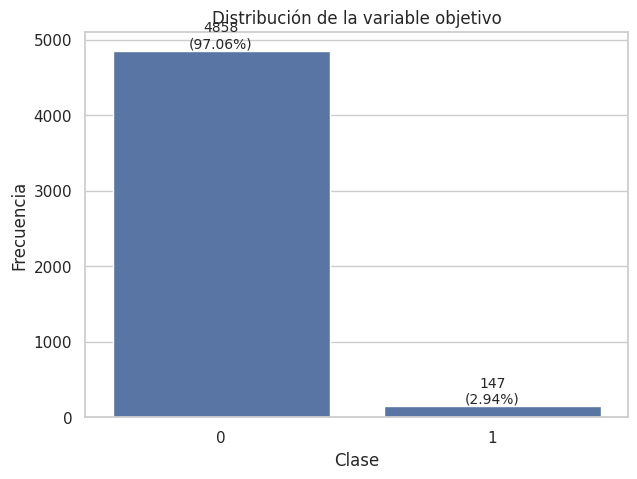

In [19]:
# Gráfico de distribución de clases
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x=target_col)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")

# Etiquetas sobre cada barra
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f"{count}\n({percentage:.2f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.show()

In [20]:
# Interpretación automática simple
minority_ratio = class_percent.min()

print(f"La clase minoritaria representa el {minority_ratio:.2f}% del total.")

if minority_ratio < 40:
    print("Conclusión: el dataset presenta desbalance de clases.")
else:
    print("Conclusión: el dataset se encuentra relativamente balanceado.")

La clase minoritaria representa el 2.94% del total.
Conclusión: el dataset presenta desbalance de clases.


✅ Se identifican varios aspectos importantes del dataset antes de iniciar la etapa de modelado. En primer lugar, se determinó que la variable objetivo presenta un desbalance severo de clases, ya que la categoría no acusatoria concentra la gran mayoría de los registros, mientras que la clase acusatoria representa una fracción muy pequeña del total. Además, se verificó que el problema corresponde a una tarea de clasificación de texto, por lo que la normalización no se entiende en el sentido tradicional de escalamiento numérico, sino como un proceso de limpieza y estandarización de las cadenas de texto; en este caso, los datos fueron normalizados mediante transformación a minúsculas, eliminación de tildes, caracteres especiales y espacios innecesarios. Finalmente, el análisis de estacionalidad o comportamiento temporal no resulta aplicable en este dataset, ya que no se dispone de una variable de fecha o tiempo que permita tratar el problema como una serie temporal.
